# Lung Cancer Classification — PyTorch + EfficientNet
**Dataset:** IQ-OTH/NCCD Lung Cancer Dataset (Local)
**Classes:** Benign / Malignant / Normal
**Model:** EfficientNetB0 pretrained + Fine-tuning
**Platform:** VS Code + Local Python Environment

## โครงสร้างโฟลเดอร์
```
D:\project\
├── lung_cancer_fixed.ipynb
├── dataset/
│   ├── train/
│   │   ├── Benign cases/
│   │   ├── Malignant cases/
│   │   └── Normal cases/
│   └── test/ 
│       └── *.png
└── best_model.pth 
```

In [20]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cpu':
    print('⚠️  ไม่พบ GPU — เทรนบน CPU จะช้ามาก')

Device: cpu
⚠️  ไม่พบ GPU — เทรนบน CPU จะช้ามาก


## 2. Config

In [21]:
DATA_ROOT = Path('dataset')  # แก้ path ตรงนี้ถ้าจำเป็น

if DATA_ROOT.exists():
    for p in sorted(DATA_ROOT.rglob('*')):
        if p.is_dir():
            n = len([f for f in p.glob('*') if f.is_file()])
            print(f'  {p}  ({n} files)')
else:
    print(f'❌ ไม่พบ {DATA_ROOT} — แก้ DATA_ROOT ให้ตรงกับ path จริง')

  dataset\test  (197 files)
  dataset\train  (0 files)
  dataset\train\Benign cases  (120 files)
  dataset\train\Malignant cases  (561 files)
  dataset\train\Normal cases  (416 files)


In [22]:
TRAIN_DIR = DATA_ROOT / 'train'
TEST_DIR  = DATA_ROOT / 'test'

CLASS_NAMES = ['Benign cases', 'Malignant cases', 'Normal cases']
SHORT_NAMES = ['Benign', 'Malignant', 'Normal']

IMG_SIZE        = 224
BATCH_SIZE      = 16
NUM_CLASSES     = 3
EPOCHS_FROZEN   = 10
EPOCHS_FINETUNE = 20
LR_FROZEN       = 1e-3
LR_FINETUNE     = 1e-5
NUM_WORKERS     = 0 if os.name == 'nt' else 2

print('Train:', TRAIN_DIR, '| exists:', TRAIN_DIR.exists())
print('Workers:', NUM_WORKERS)

Train: dataset\train | exists: True
Workers: 0


## 3. EDA — Dataset Statistics

In [23]:
# นับจำนวนรูปแต่ละ class
counts = {}
for cls in CLASS_NAMES:
    p = TRAIN_DIR / cls
    n = len([f for f in p.glob('*') if f.is_file()]) if p.is_dir() else 0
    counts[cls] = n
    print(f'  {cls}: {n}')
total = sum(counts.values())
print(f'Total: {total}')

  Benign cases: 120
  Malignant cases: 561
  Normal cases: 416
Total: 1097


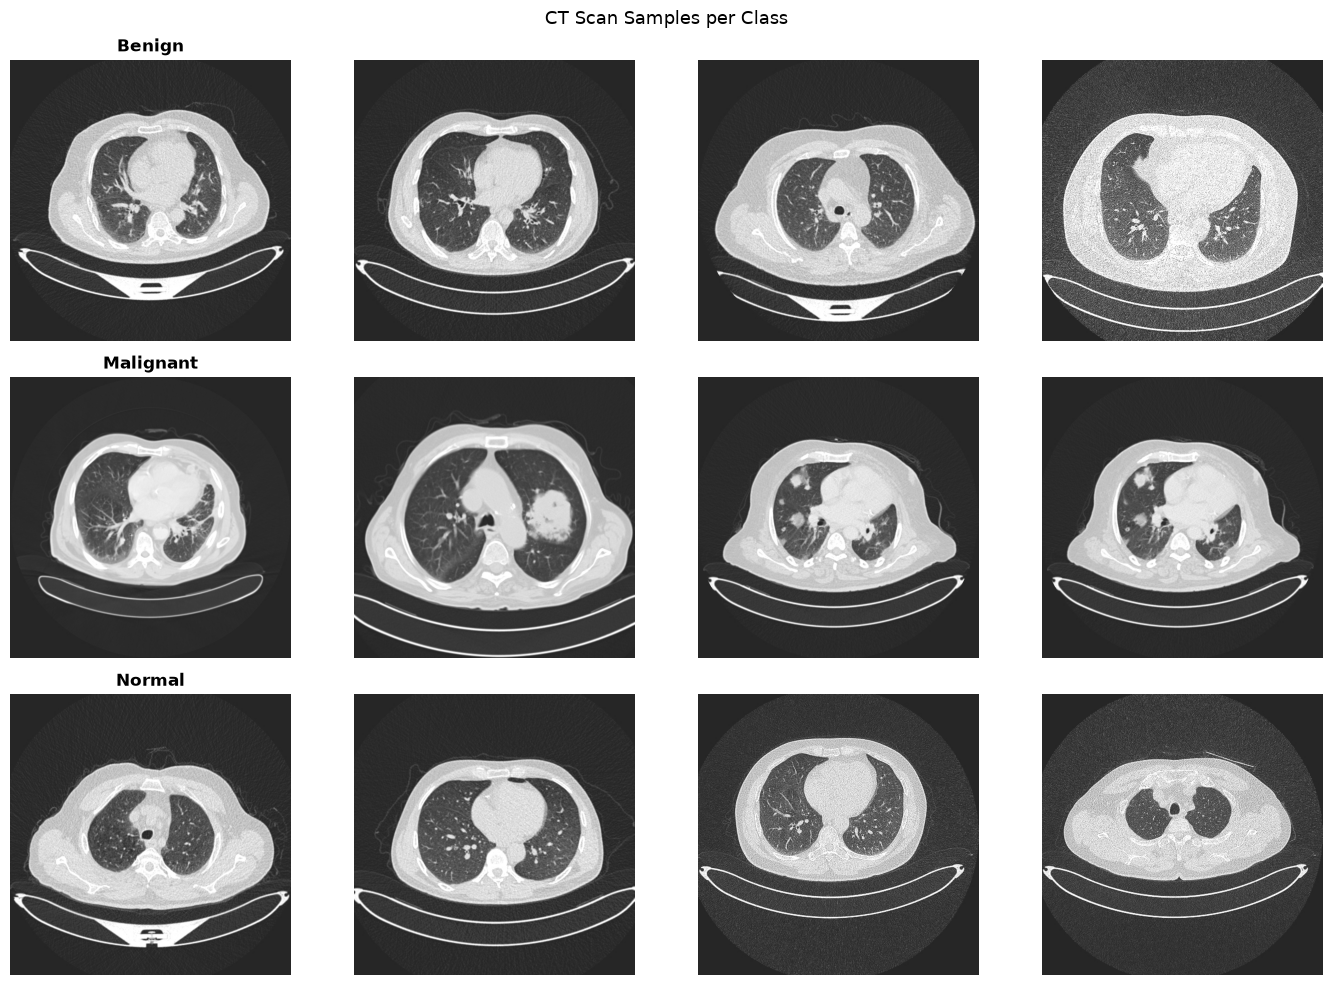

In [24]:
# ตัวอย่าง CT scan แต่ละ class
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for row, cls in enumerate(CLASS_NAMES):
    imgs = [f for f in (TRAIN_DIR/cls).glob('*') if f.is_file()][:4]
    for col, p in enumerate(imgs):
        axes[row][col].imshow(Image.open(p).convert('RGB'))
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(SHORT_NAMES[row], fontsize=12, fontweight='bold')
plt.suptitle('CT Scan Samples per Class', fontsize=13)
plt.tight_layout(); plt.show()

In [25]:
# เก็บ stat ของทุกรูป
stats = []
for cls in CLASS_NAMES:
    d = TRAIN_DIR / cls
    if not d.is_dir(): continue
    for f in d.glob('*'):
        if f.suffix.lower() in ['.jpg','.jpeg','.png','.bmp','.tif','.tiff']:
            img = Image.open(f).convert('RGB')
            arr = np.array(img)
            stats.append({
                'class'      : cls.replace(' cases',''),
                'width'      : img.size[0],
                'height'     : img.size[1],
                'aspect'     : img.size[0]/img.size[1],
                'brightness' : arr.mean(),
                'std'        : arr.mean(axis=2).std(),
                'mean_r'     : arr[:,:,0].mean(),
                'mean_g'     : arr[:,:,1].mean(),
                'mean_b'     : arr[:,:,2].mean(),
            })

df = pd.DataFrame(stats)

# Summary table
summary = df.groupby('class').agg(
    count       =('width','count'),
    avg_width   =('width','mean'),
    avg_height  =('height','mean'),
    avg_bright  =('brightness','mean'),
    std_bright  =('brightness','std'),
    avg_texture =('std','mean'),
    min_width   =('width','min'),
    max_width   =('width','max'),
).round(2)
print(summary.to_string())


           count  avg_width  avg_height  avg_bright  std_bright  avg_texture  min_width  max_width
class                                                                                             
Benign       120     512.00      512.00      101.18       10.27        76.55        512        512
Malignant    561     532.56      511.81      105.92       13.89        76.26        511        801
Normal       416     511.99      511.56      103.52        9.86        75.86        506        512


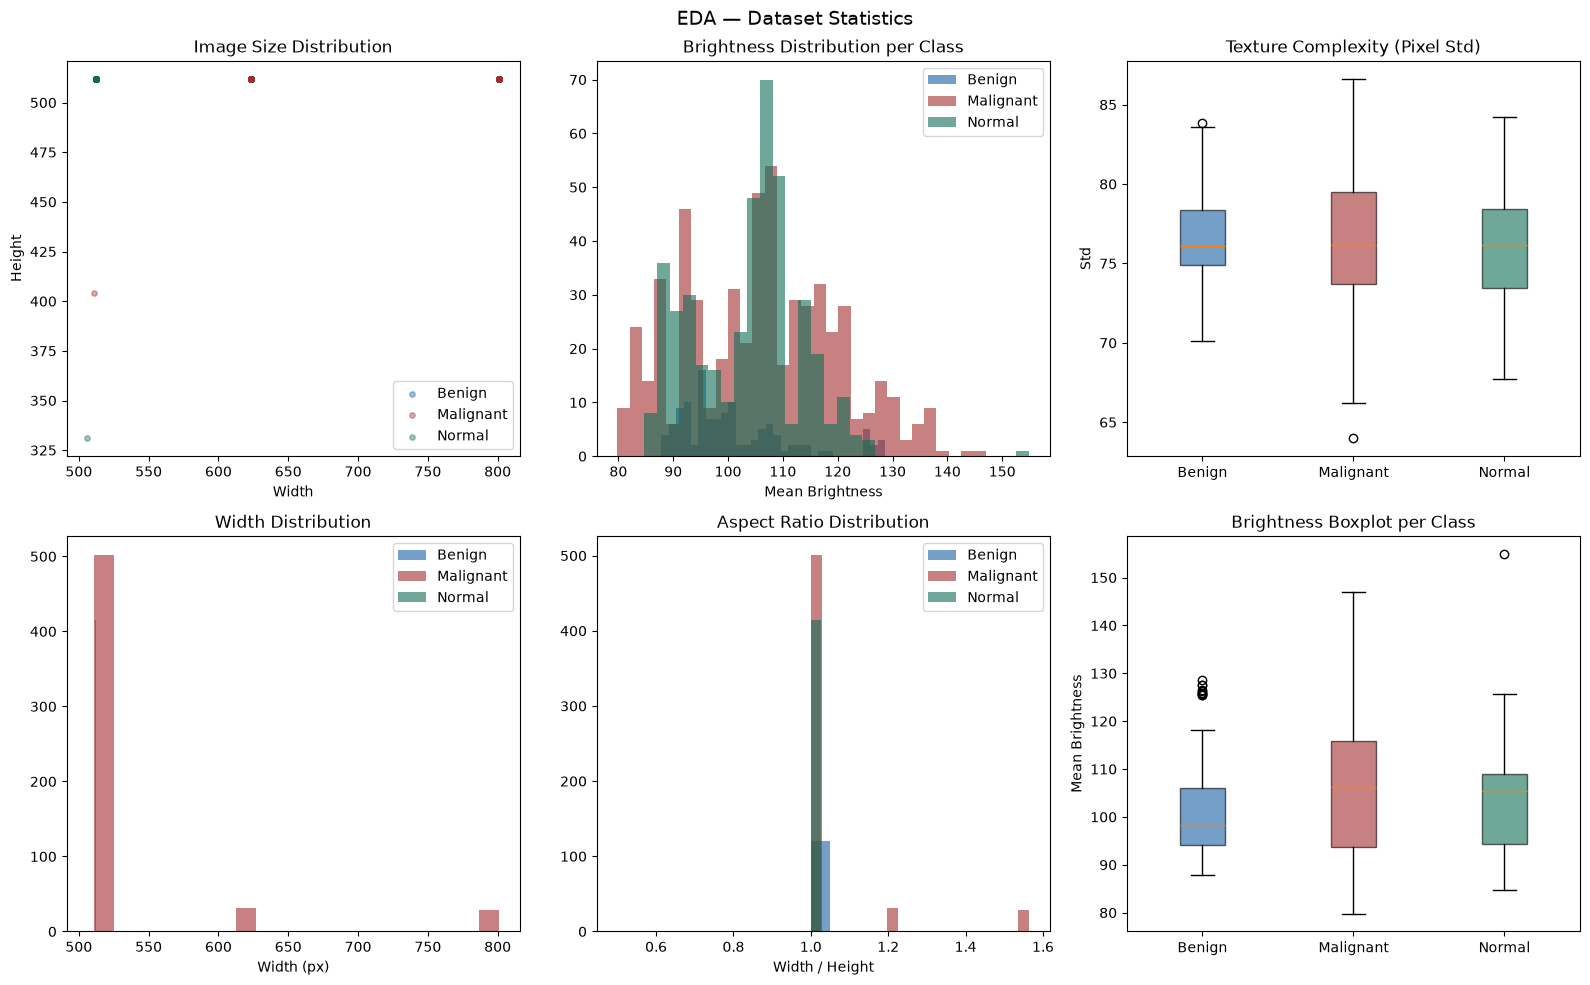

In [26]:
colors = ['#185FA5','#A32D2D','#0F6E56']
classes = df['class'].unique()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Image size scatter
for cls, c in zip(classes, colors):
    sub = df[df['class']==cls]
    axes[0][0].scatter(sub['width'], sub['height'], alpha=0.4, label=cls, color=c, s=15)
axes[0][0].set_title('Image Size Distribution')
axes[0][0].set_xlabel('Width'); axes[0][0].set_ylabel('Height')
axes[0][0].legend()

# 2. Brightness histogram
for cls, c in zip(classes, colors):
    axes[0][1].hist(df[df['class']==cls]['brightness'], bins=30, alpha=0.6, label=cls, color=c)
axes[0][1].set_title('Brightness Distribution per Class')
axes[0][1].set_xlabel('Mean Brightness'); axes[0][1].legend()

# 3. Texture std boxplot
bp = axes[0][2].boxplot([df[df['class']==c]['std'].values for c in classes],
                         patch_artist=True)
axes[0][2].set_xticklabels(classes)
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[0][2].set_title('Texture Complexity (Pixel Std)')
axes[0][2].set_ylabel('Std')

# 4. Width histogram
for cls, c in zip(classes, colors):
    axes[1][0].hist(df[df['class']==cls]['width'], bins=20, alpha=0.6, label=cls, color=c)
axes[1][0].set_title('Width Distribution')
axes[1][0].set_xlabel('Width (px)'); axes[1][0].legend()

# 5. Aspect ratio histogram
for cls, c in zip(classes, colors):
    axes[1][1].hist(df[df['class']==cls]['aspect'], bins=20, alpha=0.6, label=cls, color=c)
axes[1][1].set_title('Aspect Ratio Distribution')
axes[1][1].set_xlabel('Width / Height'); axes[1][1].legend()

bp2 = axes[1][2].boxplot([df[df['class']==c]['brightness'].values for c in classes],
                          patch_artist=True)
axes[1][2].set_xticklabels(classes)
for patch, c in zip(bp2['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[1][2].set_title('Brightness Boxplot per Class')
axes[1][2].set_ylabel('Mean Brightness')

plt.suptitle('EDA — Dataset Statistics', fontsize=14)
plt.tight_layout()
plt.savefig('eda_stats.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Dataset & Transforms

In [27]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomAffine(degrees=0, translate=(0.05,0.05), shear=5),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.15, scale=(0.02,0.1)),
])
val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class LungDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p, y = self.samples[i]
        return self.transform(Image.open(p).convert('RGB')), y
    def get_labels(self): return [s[1] for s in self.samples]

# โหลดทุกรูปแล้วแบ่ง 80/20 stratified
c2i = {c: i for i, c in enumerate(CLASS_NAMES)}
all_samples = []
for cls in CLASS_NAMES:
    d = TRAIN_DIR / cls
    if not d.is_dir(): print(f'WARNING: {d} not found'); continue
    for f in d.glob('*'):
        if f.suffix.lower() in ['.jpg','.jpeg','.png','.bmp','.tif','.tiff']:
            all_samples.append((f, c2i[cls]))

train_samples, val_samples = train_test_split(
    all_samples, test_size=0.2,
    stratify=[s[1] for s in all_samples], random_state=42
)

train_ds = LungDataset(train_samples, train_transforms)
val_ds   = LungDataset(val_samples,   val_transforms)
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}')
print(f'Val dist: {Counter(val_ds.get_labels())}  (0=Benign,1=Malignant,2=Normal)')

Train: 877  Val: 220
Val dist: Counter({1: 113, 2: 83, 0: 24})  (0=Benign,1=Malignant,2=Normal)


## 5. WeightedRandomSampler — แก้ Class Imbalance

In [28]:
train_labels = train_ds.get_labels()
cls_counts   = Counter(train_labels)
n_total      = len(train_labels)

# คำนวณ base weights ก่อน
cw = torch.zeros(NUM_CLASSES)
for idx, cnt in cls_counts.items():
    cw[idx] = n_total / (NUM_CLASSES * cnt)

cw[2] = cw[2] * 2.0 

print('Class weights (adjusted):')
for i, (n, w) in enumerate(zip(SHORT_NAMES, cw)):
    print(f'  {n:10s}: {w:.3f}')

sample_w = [cw[lbl].item() for lbl in train_labels]
sampler  = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(val_ds,   BATCH_SIZE, shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)
print(f'Train batches: {len(train_loader)}  Val batches: {len(test_loader)}')

Class weights (adjusted):
  Benign    : 3.045
  Malignant : 0.653
  Normal    : 1.756
Train batches: 55  Val batches: 14


## 6. Focal Loss

In [29]:
class FocalLoss(nn.Module):
    """FL = -alpha*(1-pt)^gamma * log(pt)
    โฟกัสกับ hard/rare samples เช่น Benign ที่มีน้อย"""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, x, y):
        ce  = nn.functional.cross_entropy(x, y, weight=self.alpha, reduction='none')
        pt  = torch.exp(-ce)
        return ((1-pt)**self.gamma * ce).mean()


criterion = FocalLoss(alpha=cw.to(DEVICE), gamma=2.0)
print('Focal Loss ready — gamma=2.0')

Focal Loss ready — gamma=2.0


## 7. Model — EfficientNetB0 + Custom Head

In [30]:
def build_model():
    m = timm.create_model('efficientnet_b0', pretrained=True)
    in_f = m.classifier.in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_f, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, NUM_CLASSES)
    )
    return m

def freeze_base(m):
    for n, p in m.named_parameters():
        p.requires_grad = ('classifier' in n)

def unfreeze_last(m, n=3):
    for name, p in m.named_parameters():
        p.requires_grad = ('classifier' in name)
    if hasattr(m, 'blocks'):
        for blk in list(m.blocks)[-n:]:
            for p in blk.parameters(): p.requires_grad = True
    for attr in ['conv_head','bn2']:
        if hasattr(m, attr):
            for p in getattr(m,attr).parameters(): p.requires_grad = True

def pcount(m):
    tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
    tot= sum(p.numel() for p in m.parameters())
    print(f'Trainable: {tr:,} / {tot:,} ({tr/tot*100:.1f}%)')


model = build_model().to(DEVICE)
pcount(model)

Trainable: 4,336,255 / 4,336,255 (100.0%)


## 8. Training Functions

In [31]:
def train_epoch(model, loader, opt, crit):
    model.train()
    loss_sum = correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward(); opt.step()
        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)
    return loss_sum/total, correct/total

@torch.no_grad()
def eval_model(model, loader, crit):
    model.eval()
    loss_sum = correct = total = 0
    preds_all, labels_all, probs_all = [], [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out   = model(x)
        probs = torch.softmax(out, 1)
        loss_sum += crit(out, y).item() * x.size(0)
        correct  += (probs.argmax(1) == y).sum().item()
        total    += x.size(0)
        preds_all.extend(probs.argmax(1).cpu().numpy())
        labels_all.extend(y.cpu().numpy())
        probs_all.extend(probs.cpu().numpy())
    return loss_sum/total, correct/total, preds_all, labels_all, probs_all

def run_phase(model, opt, sch, epochs, name, hist):
    best = 0
    for ep in range(1, epochs+1):
        tl, ta = train_epoch(model, train_loader, opt, criterion)
        vl, va, _, _, _ = eval_model(model, test_loader, criterion)
        if isinstance(sch, optim.lr_scheduler.ReduceLROnPlateau): sch.step(vl)
        else: sch.step()
        hist['tl'].append(tl); hist['vl'].append(vl)
        hist['ta'].append(ta); hist['va'].append(va)
        mark = ''
        if va > best:
            best = va
            torch.save(model.state_dict(), 'best_model.pth')
            mark = ' ✓'
        print(f'[{name}] {ep:02d}/{epochs} | loss {tl:.4f}/{vl:.4f} | acc {ta:.4f}/{va:.4f}{mark}')
    return hist

hist = {'tl':[],'vl':[],'ta':[],'va':[]}
print('Ready')

Ready


## 9. Phase 1 — Frozen Base

In [32]:
print('=== Phase 1: Train head only ===')
freeze_base(model); pcount(model)

opt1 = optim.Adam(filter(lambda p:p.requires_grad, model.parameters()), lr=LR_FROZEN)
sch1 = optim.lr_scheduler.ReduceLROnPlateau(opt1, mode='min', patience=3, factor=0.5)
hist = run_phase(model, opt1, sch1, EPOCHS_FROZEN, 'FROZEN', hist)

=== Phase 1: Train head only ===
Trainable: 328,707 / 4,336,255 (7.6%)


d:\project\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[FROZEN] 01/10 | loss 0.9114/0.5074 | acc 0.5462/0.7636 ✓
[FROZEN] 02/10 | loss 0.7120/0.4688 | acc 0.6887/0.7773 ✓
[FROZEN] 03/10 | loss 0.6522/0.4278 | acc 0.7206/0.7955 ✓
[FROZEN] 04/10 | loss 0.6504/0.3940 | acc 0.7491/0.8455 ✓
[FROZEN] 05/10 | loss 0.5598/0.3844 | acc 0.7719/0.8455
[FROZEN] 06/10 | loss 0.5310/0.3512 | acc 0.7697/0.8636 ✓
[FROZEN] 07/10 | loss 0.5553/0.3723 | acc 0.7560/0.8227
[FROZEN] 08/10 | loss 0.4664/0.3562 | acc 0.7982/0.8864 ✓
[FROZEN] 09/10 | loss 0.5219/0.3612 | acc 0.8016/0.8682
[FROZEN] 10/10 | loss 0.4859/0.3510 | acc 0.7834/0.8091


## 10. Phase 2 — Fine-tuning

In [33]:
print('=== Phase 2: Fine-tune last 3 blocks ===')
unfreeze_last(model, n=3); pcount(model)

opt2 = optim.AdamW(filter(lambda p:p.requires_grad, model.parameters()), lr=LR_FINETUNE, weight_decay=1e-4)
sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS_FINETUNE, eta_min=1e-7)
hist = run_phase(model, opt2, sch2, EPOCHS_FINETUNE, 'FINETUNE', hist)

=== Phase 2: Fine-tune last 3 blocks ===
Trainable: 4,027,595 / 4,336,255 (92.9%)
[FINETUNE] 01/20 | loss 0.4830/0.3042 | acc 0.7708/0.8955 ✓
[FINETUNE] 02/20 | loss 0.4213/0.2998 | acc 0.8119/0.8909
[FINETUNE] 03/20 | loss 0.4297/0.2850 | acc 0.8005/0.8864
[FINETUNE] 04/20 | loss 0.3781/0.3067 | acc 0.8461/0.8591
[FINETUNE] 05/20 | loss 0.3536/0.2938 | acc 0.8575/0.8864
[FINETUNE] 06/20 | loss 0.3677/0.2827 | acc 0.8563/0.9000 ✓
[FINETUNE] 07/20 | loss 0.3735/0.2829 | acc 0.8483/0.8955
[FINETUNE] 08/20 | loss 0.3306/0.2869 | acc 0.8643/0.8864
[FINETUNE] 09/20 | loss 0.3281/0.2676 | acc 0.8575/0.9182 ✓
[FINETUNE] 10/20 | loss 0.2980/0.2597 | acc 0.8643/0.9045
[FINETUNE] 11/20 | loss 0.3035/0.2905 | acc 0.8848/0.8773
[FINETUNE] 12/20 | loss 0.3212/0.2739 | acc 0.8780/0.9000
[FINETUNE] 13/20 | loss 0.2864/0.2749 | acc 0.8848/0.8909
[FINETUNE] 14/20 | loss 0.2842/0.2819 | acc 0.8848/0.8955
[FINETUNE] 15/20 | loss 0.2799/0.2679 | acc 0.8803/0.9000
[FINETUNE] 16/20 | loss 0.3035/0.2925 | ac

## 11. Training Curves

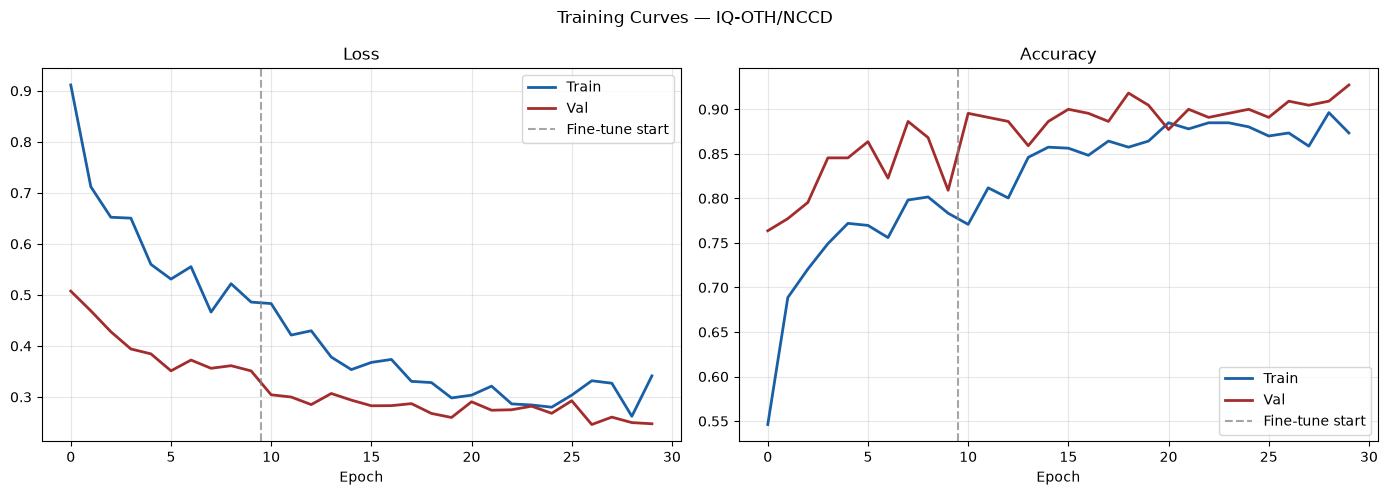

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr_k, vl_k, title in [(axes[0],'tl','vl','Loss'),(axes[1],'ta','va','Accuracy')]:
    ax.plot(hist[tr_k], label='Train', color='#185FA5', lw=2)
    ax.plot(hist[vl_k], label='Val',   color='#A32D2D', lw=2)
    ax.axvline(EPOCHS_FROZEN-0.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Training Curves — IQ-OTH/NCCD')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Evaluate Best Model

In [35]:
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE, weights_only=True))
_, acc, preds, labels, probs = eval_model(model, test_loader, criterion)
print(f'Test Accuracy: {acc:.4f}\n')
print(classification_report(labels, preds, target_names=SHORT_NAMES))

Test Accuracy: 0.9273

              precision    recall  f1-score   support

      Benign       0.67      0.75      0.71        24
   Malignant       0.99      1.00      1.00       113
      Normal       0.92      0.88      0.90        83

    accuracy                           0.93       220
   macro avg       0.86      0.88      0.87       220
weighted avg       0.93      0.93      0.93       220



## 13. Confusion Matrix

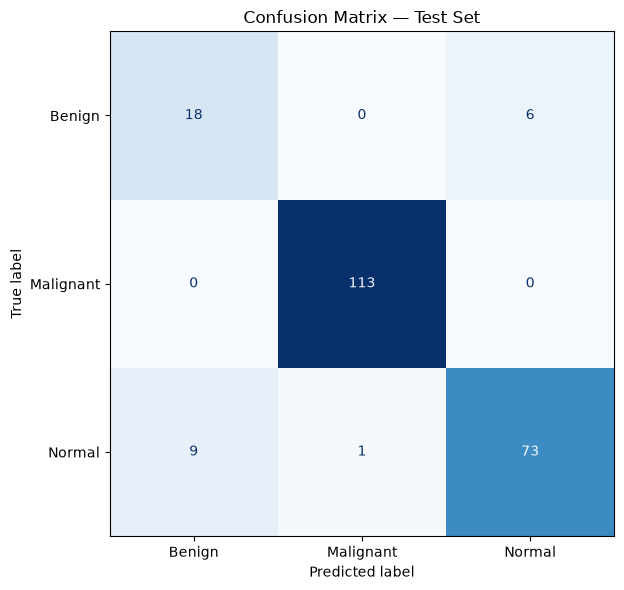


Recall per class:
  Benign    : 0.7500  ← ⚠️ Benign น้อย ระวัง
  Malignant : 1.0000  
  Normal    : 0.8795  


In [36]:
cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm, display_labels=SHORT_NAMES).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRecall per class:')
for i, name in enumerate(SHORT_NAMES):
    r = cm[i,i] / cm[i].sum()
    note = '← ⚠️ Benign น้อย ระวัง' if name=='Benign' else ''
    print(f'  {name:10s}: {r:.4f}  {note}')

## 14. AUC-ROC per Class

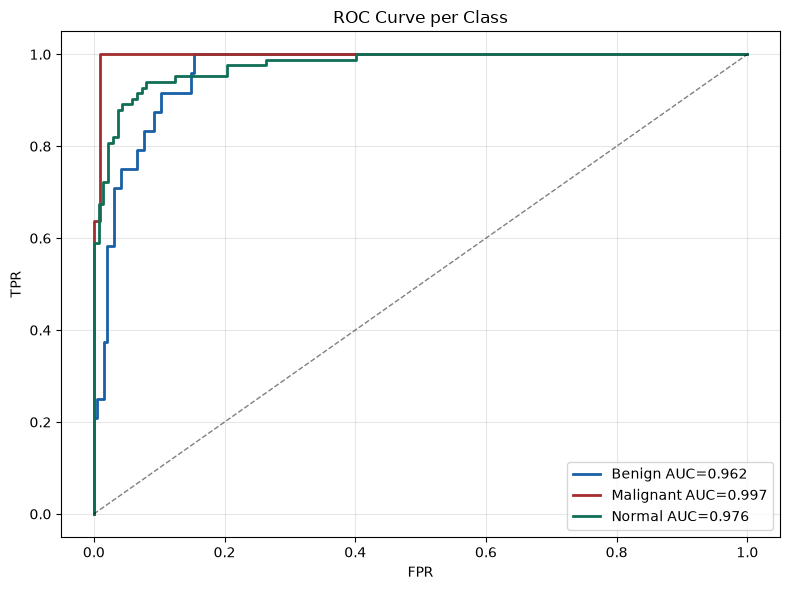

In [37]:
lb  = label_binarize(labels, classes=[0,1,2])
pa  = np.array(probs)
clr = ['#185FA5','#A32D2D','#0F6E56']
fig, ax = plt.subplots(figsize=(8,6))
for i,(n,c) in enumerate(zip(SHORT_NAMES, clr)):
    fpr,tpr,_ = roc_curve(lb[:,i], pa[:,i])
    ax.plot(fpr,tpr,color=c,lw=2,label=f'{n} AUC={auc(fpr,tpr):.3f}')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve per Class'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Grad-CAM — โมเดลโฟกัสส่วนไหนของ CT Scan

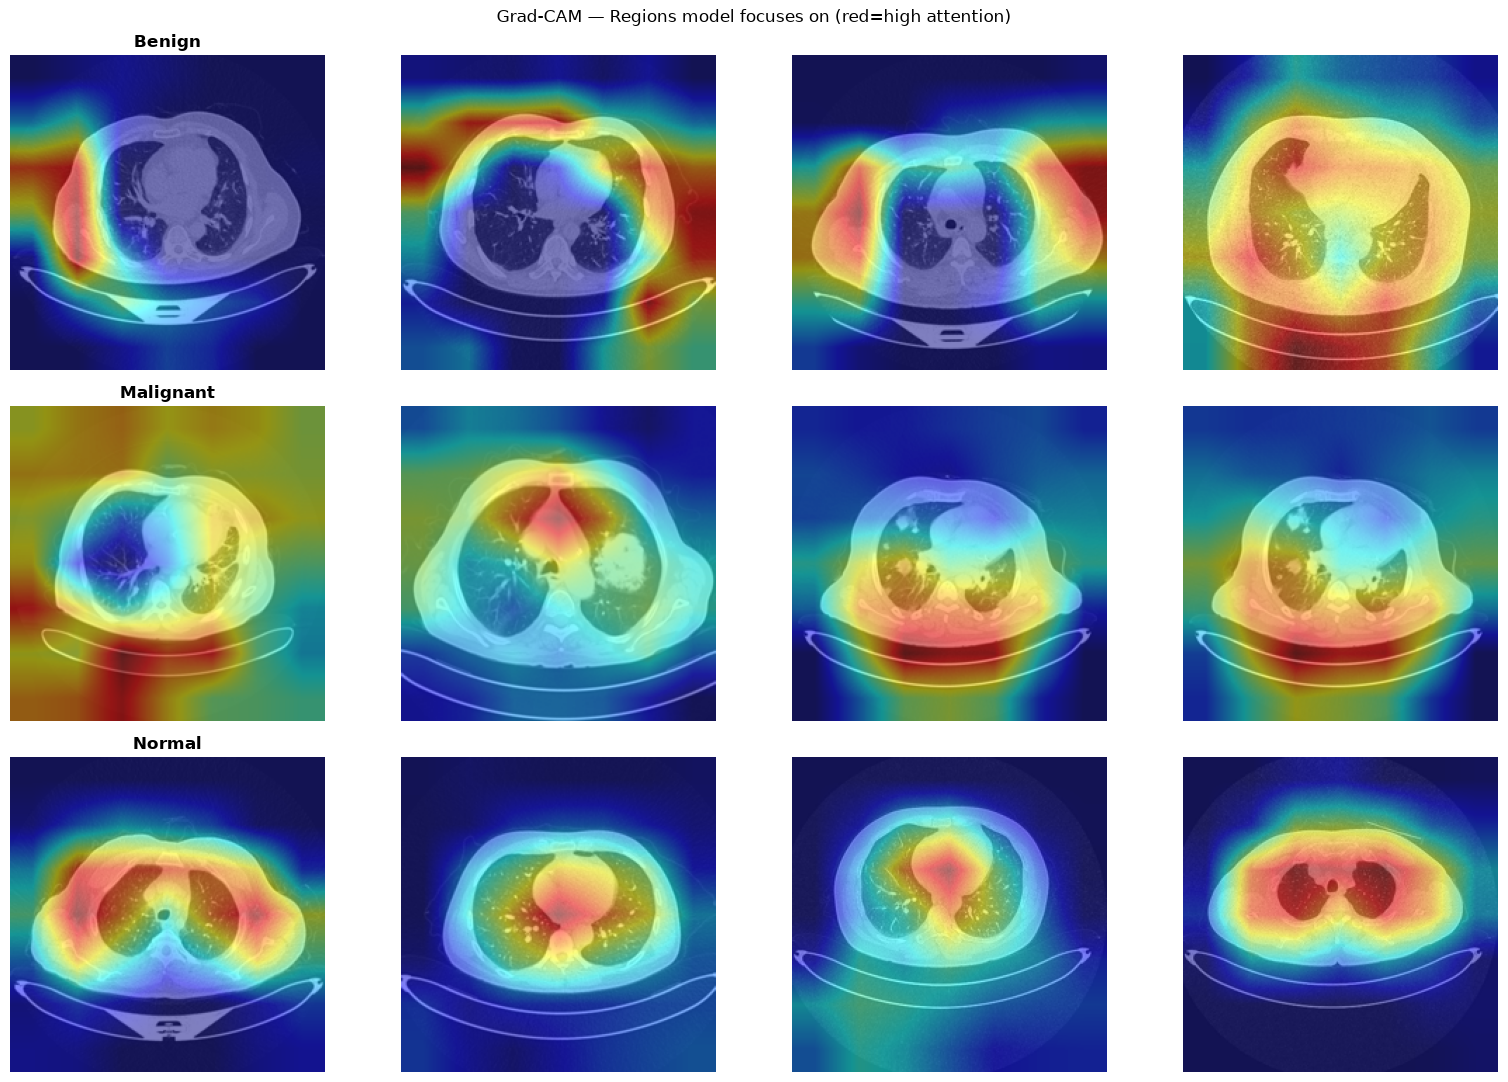

In [38]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam = GradCAM(model=model, target_layers=[model.blocks[-1]])
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

for row, (cls, idx) in enumerate(zip(CLASS_NAMES, range(3))):
    imgs = [f for f in (TRAIN_DIR/cls).glob('*') if f.is_file()][:4]
    for col, p in enumerate(imgs):
        raw   = Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        raw_n = np.array(raw).astype(np.float32) / 255.0
        t     = val_transforms(raw).unsqueeze(0).to(DEVICE)
        gc    = cam(input_tensor=t, targets=[ClassifierOutputTarget(idx)])
        vis   = show_cam_on_image(raw_n, gc[0], use_rgb=True)
        axes[row][col].imshow(vis); axes[row][col].axis('off')
        if col == 0: axes[row][col].set_title(SHORT_NAMES[row], fontsize=12, fontweight='bold')

plt.suptitle('Grad-CAM — Regions model focuses on (red=high attention)', fontsize=12)
plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()

## SUMMARY

In [40]:
from sklearn.metrics import precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

# ===== Detailed Statistics =====

# 1. Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    labels, preds, labels=[0,1,2]
)

df_metrics = pd.DataFrame({
    'Class'    : SHORT_NAMES,
    'Support'  : support,
    'Precision': precision.round(4),
    'Recall'   : recall.round(4),
    'F1-Score' : f1.round(4),
})
df_metrics['Precision%'] = (df_metrics['Precision']*100).round(2)
df_metrics['Recall%']    = (df_metrics['Recall']*100).round(2)
df_metrics['F1%']        = (df_metrics['F1-Score']*100).round(2)

print('='*55)
print('  Per-Class Metrics')
print('='*55)
print(df_metrics[['Class','Support','Precision%','Recall%','F1%']].to_string(index=False))

# 2. Overall metrics
total_correct = cm.diagonal().sum()
total_samples = cm.sum()
overall_acc   = total_correct / total_samples
macro_p       = precision.mean()
macro_r       = recall.mean()
macro_f1      = f1.mean()
_, _, wf1, _  = precision_recall_fscore_support(labels, preds, average='weighted')

print(f'\n{"="*55}')
print('  Overall Metrics')
print(f'{"="*55}')
print(f'  Accuracy         : {overall_acc*100:.2f}%  ({total_correct}/{total_samples})')
print(f'  Macro Precision  : {macro_p*100:.2f}%')
print(f'  Macro Recall     : {macro_r*100:.2f}%')
print(f'  Macro F1         : {macro_f1*100:.2f}%')
print(f'  Weighted F1      : {wf1*100:.2f}%')

# 3. TP/FP/FN/TN per class
print(f'\n{"="*55}')
print('  Confusion Matrix Analysis')
print(f'{"="*55}')
for i, cls in enumerate(SHORT_NAMES):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f'\n  [{cls}]')
    print(f'    TP={tp}  FP={fp}  FN={fn}  TN={tn}')
    print(f'    Precision  : {tp/(tp+fp)*100:.2f}%' if (tp+fp)>0 else '    Precision  : N/A')
    print(f'    Recall     : {tp/(tp+fn)*100:.2f}%' if (tp+fn)>0 else '    Recall     : N/A')
    print(f'    Specificity: {spec*100:.2f}%')

# 4. AUC per class
lb = label_binarize(labels, classes=[0,1,2])
pa = np.array(probs)

print(f'\n{"="*55}')
print('  AUC-ROC per Class')
print(f'{"="*55}')
for i, cls in enumerate(SHORT_NAMES):
    a = roc_auc_score(lb[:, i], pa[:, i])
    bar = '█' * int(a * 20)
    print(f'  {cls:10s}: {a:.4f}  {bar}')
print(f'\n  Macro AUC: {roc_auc_score(lb, pa, average="macro"):.4f}')

# 5. Summary verdict
print(f'\n{"="*55}')
print('  Summary')
print(f'{"="*55}')
for i, cls in enumerate(SHORT_NAMES):
    r = recall[i]
    status = '✅ ดีมาก' if r >= 0.90 else '⚠️  พอใช้' if r >= 0.70 else '❌ ต้องปรับปรุง'
    print(f'  {cls:10s}  Recall {r*100:.1f}%  {status}')

  Per-Class Metrics
    Class  Support  Precision%  Recall%   F1%
   Benign       24       66.67    75.00 70.59
Malignant      113       99.12   100.00 99.56
   Normal       83       92.41    87.95 90.12

  Overall Metrics
  Accuracy         : 92.73%  (204/220)
  Macro Precision  : 86.06%
  Macro Recall     : 87.65%
  Macro F1         : 86.76%
  Weighted F1      : 92.84%

  Confusion Matrix Analysis

  [Benign]
    TP=18  FP=9  FN=6  TN=187
    Precision  : 66.67%
    Recall     : 75.00%
    Specificity: 95.41%

  [Malignant]
    TP=113  FP=1  FN=0  TN=106
    Precision  : 99.12%
    Recall     : 100.00%
    Specificity: 99.07%

  [Normal]
    TP=73  FP=6  FN=10  TN=131
    Precision  : 92.41%
    Recall     : 87.95%
    Specificity: 95.62%

  AUC-ROC per Class
  Benign    : 0.9615  ███████████████████
  Malignant : 0.9966  ███████████████████
  Normal    : 0.9760  ███████████████████

  Macro AUC: 0.9780

  Summary
  Benign      Recall 75.0%  ⚠️  พอใช้
  Malignant   Recall 100.0%  ✅ ด